#Transformer

##0. Imports and configs

In [1]:
import os
from pathlib import Path
import json
import pandas as pd
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


In [3]:
# Fixing seed to remove randomness, for better comparisons
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

##A. Local Setup

In [4]:
# DATA_DIR = Path('./data')# Path to dataset

##B. Colab Setup

In [4]:
!pip -q install gdown

DATA_DIR = Path("/content/ML_Exam_Project")
DATA_DIR.mkdir(exist_ok=True)

FOLDER_URL = "https://drive.google.com/drive/folders/17Cklb8rQ2DJt_NoWPCbgqkd16V1MOXiw?usp=sharing"

!gdown --folder "$FOLDER_URL" -O "$DATA_DIR"

Retrieving folder contents
Processing file 1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2 test_id.jsonl
Processing file 1utlrU9pwh-Ou1LomUKtZXaB6HemPzI9s test_long.jsonl
Processing file 17YHqluGDYL1izzYFYWON5FzDZZaCcist test_ood.jsonl
Processing file 19yevHfLO23hJ9UEs31F0wa0I9YwESMqP train_augmented.jsonl
Processing file 1uZ9iQSPtoYhlb1Kt2jCigoFePQGsgLRb train.jsonl
Processing file 1vt1B-Optfa19JqtnNSOuL5Ao7tq1ySap validation_augmented.jsonl
Processing file 1knh_LSuwKqZeUn5cbFJ9bfnu03iYQKJ0 validation.jsonl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2
To: /content/ML_Exam_Project/test_id.jsonl
100% 222k/222k [00:00<00:00, 111MB/s]
Downloading...
From: https://drive.google.com/uc?id=1utlrU9pwh-Ou1LomUKtZXaB6HemPzI9s
To: /content/ML_Exam_Project/test_long.jsonl
100% 182k/182k [00:00<00:00, 93.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=17YHql

##Data

###1.1 File Sanity Check

In [5]:
expected_files = [
    "train.jsonl",
    "validation.jsonl",
    "test_id.jsonl",
    "test_ood.jsonl",
    "test_long.jsonl",
    "train_augmented.jsonl",
    "validation_augmented.jsonl"
]

for filename in expected_files:
    path = DATA_DIR / filename
    assert path.exists(), f"Missing file: {path}"

print("All dataset files found:")
for filename in expected_files:
    print(" -", DATA_DIR / filename)

All dataset files found:
 - /content/ML_Exam_Project/train.jsonl
 - /content/ML_Exam_Project/validation.jsonl
 - /content/ML_Exam_Project/test_id.jsonl
 - /content/ML_Exam_Project/test_ood.jsonl
 - /content/ML_Exam_Project/test_long.jsonl
 - /content/ML_Exam_Project/train_augmented.jsonl
 - /content/ML_Exam_Project/validation_augmented.jsonl


###1.2 Data Loading

In [6]:
# Function to load jsonl into pandas df object
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

In [7]:
train_df = load_jsonl(DATA_DIR / "train.jsonl")
train_augmented_df = load_jsonl(DATA_DIR / "train_augmented.jsonl")
validation_df = load_jsonl(DATA_DIR / "validation.jsonl")
validation_augmented_df = load_jsonl(DATA_DIR / "validation_augmented.jsonl")
test_id_df = load_jsonl(DATA_DIR / "test_id.jsonl")
test_ood_df = load_jsonl(DATA_DIR / "test_ood.jsonl")
test_long_df = load_jsonl(DATA_DIR / "test_long.jsonl")

###1.3 Understanding Data

####1.3.1 Data Shapes

In [8]:
print("Train:", train_df.shape)
print("Train augmented:", train_augmented_df.shape)
print("Validation:", validation_df.shape)
print("Validation augmented:", validation_augmented_df.shape)
print("Test ID:", test_id_df.shape)
print("Test OOD:", test_ood_df.shape)
print("Test long:", test_long_df.shape)

Train: (12000, 6)
Train augmented: (12000, 6)
Validation: (2000, 6)
Validation augmented: (2000, 6)
Test ID: (2000, 6)
Test OOD: (2000, 6)
Test long: (1500, 6)


####1.3.2 Data Examples

In [9]:
train_df.head()

,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


####1.3.3 Test For Whitespace

It is important to test for white spaces to know if it is required to strip them away because whitespaces such as (1 + 1 3) is a wrong mathematical expression. Furthermore, our plan to use a binary tree to linearize mathematical expression may run into issues if we use whitespace to separate terms

In [10]:
def check_for_whitespace(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    return combined_df["expression"].astype(str).str.contains(r"\s").any()

####1.3.4 Test For Unary Operators

Unary operators like -5 have to be considered when constructing expression trees, if unary operators exist, we have to preprocess our data in a way where the sign and the number are interpreted as one (i.e. "-5" instead of "- 5")

In [11]:
def check_for_unary_operators(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    def has_unary(expr):
        for i, ch in enumerate(expr):
            if ch in "+-":
                if i == 0:
                    return True  # starts with + or -
                prev = expr[i - 1]
                if prev in "(-+":
                    return True
        return False

    return combined_df["expression"].apply(has_unary).any()

####1.3.5 Data Preprocessing and Transformation

In this step, we aim to represent our input data in a different form in an attempt to help our models learn better

#####1.3.5.1 ExpressionTree, Prefix and Postfix

In [12]:
# Node Structure (Intermediary structure required to build trees)
class Node:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

In [13]:
# ExpressionTree Class (class used to represent mathematical expression)
class ExpressionTree:
    def __init__(self, root_node):
        self.root_node = root_node

    def get_root_node(self):
        return self.root_node

    def to_postfix(self):
        def dfs(node):
            if node is None:
                return []
            return dfs(node.left) + dfs(node.right) + [str(node.value)]

        return " ".join(dfs(self.root_node))

    def to_prefix(self):
        def dfs(node):
            if node is None:
                return []
            return [str(node.value)] + dfs(node.left) + dfs(node.right)

        return " ".join(dfs(self.root_node))

    def get_depth(self):
        def dfs(node, current_depth):
            if node is None:
                return current_depth - 1

            left_depth = dfs(node.left, current_depth + 1)
            right_depth = dfs(node.right, current_depth + 1)

            return max(left_depth, right_depth)

        if self.root_node is None:
            return 0

        return dfs(self.root_node, 1)

    def get_operator_count(self):
        operators = "+-"

        def dfs(node):
            if node is None:
                return 0

            count = 1 if str(node.value) in operators else 0

            count += dfs(node.left)
            count += dfs(node.right)

            return count

        return dfs(self.root_node)

In [14]:
def reduce(operator_stack, operand_stack):
    op = operator_stack.pop()

    right = operand_stack.pop()
    left = operand_stack.pop()

    operand_stack.append(Node(op, left, right))


def build_tree_with_expression(expression):
    subtree_stack = []
    operator_stack = []

    for ch in expression:

        if ch.isnumeric():
            subtree_stack.append(Node(ch))

        elif ch == '(':
            operator_stack.append(ch)

        elif ch == ')':
            while operator_stack[-1] != '(':
                reduce(operator_stack, subtree_stack)

            operator_stack.pop()  # remove '('

        elif ch in '+-':

            while (
                operator_stack
                and operator_stack[-1] != '('
            ):
                reduce(operator_stack, subtree_stack)

            operator_stack.append(ch)

    while operator_stack:
        reduce(operator_stack, subtree_stack)

    root = subtree_stack.pop()
    return ExpressionTree(root)

expression = "5-(6-5)+8+8"
build_tree_with_expression(expression).to_postfix()

'5 6 5 - - 8 + 8 +'

#####1.3.5.2 Target Value Normalization

Normalizing the target variable (output) can help improve model performance and stability during training, especially with regression tasks. By scaling the target values, the model can learn more efficiently. We will normalize `y_train` and `y_val` using the mean and standard deviation calculated from `y_train`.

In [16]:
# Calculate mean and standard deviation from training targets
#y_mean = train_df["value"].mean()
#y_std = train_df["value"].std()

#print(f"Training target mean: {y_mean:.2f}")
#print(f"Training target standard deviation: {y_std:.2f}")

In [17]:
#def normalize_target_value(value,mean,std):
#    return (value - mean) / std

#def denormalize_target_value(normalized_value, mean, std):
#    return normalized_value * std + mean

####1.3.6 Applying Transformation
In this step, we apply the previously discussed preprocessing steps

In [18]:
#def apply_transformation(df):
#    df["normalized_value"] = df["value"].apply(lambda y: normalize_target_value(y, y_mean, y_std))
#    df["prefix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_prefix())
#    df["postfix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_postfix())

#    return df

In [19]:
#train_df = apply_transformation(train_df)
#validation_df = apply_transformation(validation_df)
#test_id_df = apply_transformation(test_id_df)
#test_ood_df = apply_transformation(test_ood_df)
#test_long_df = apply_transformation(test_long_df)

train_df.head()

,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


####1.3.7 Summary Of Data
Here, we create a function to give a summary of our data so we can compare the different data splits

In [15]:
# Function to return summary of data
# It is possible to calculate the summary of multiple data split together by passing them in together
def summary(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    result = pd.DataFrame({
        "mean": combined_df.mean(numeric_only=True),
        "min": combined_df.min(numeric_only=True),
        "max": combined_df.max(numeric_only=True),
    })

    # Expecting comparison of data split with different size, so we have to normalise for more meaningful comparison
    result.loc["value", "positive_ratio"] = (combined_df["value"] > 0).mean()
    result.loc["value", "negative_ratio"] = (combined_df["value"] < 0).mean()
    result.loc["value", "zero_ratio"] = (combined_df["value"] == 0).mean()

    mode = combined_df.mode(numeric_only=True).iloc[0]
    result["mode"] = mode

    return result

In [16]:
display(summary(train_df))
display(summary(train_augmented_df))
display(summary(validation_df))
display(summary(validation_augmented_df))
display(summary(test_id_df))
display(summary(test_ood_df))
display(summary(test_long_df))

,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.860750,-36,46,0.65725,0.306167,0.036583,2
length,9.607000,5,19,NaN,NaN,NaN,7
operator_count,3.489917,2,5,NaN,NaN,NaN,4
depth,3.689917,3,6,NaN,NaN,NaN,4


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.863667,-36,46,0.657417,0.30625,0.036333,2
length,9.621500,5,33,NaN,NaN,NaN,7
operator_count,3.496250,2,13,NaN,NaN,NaN,4
depth,4.012250,3,11,NaN,NaN,NaN,3


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.585,-32,47,0.64,0.323,0.037,4.0
length,9.604,5,19,NaN,NaN,NaN,7.0
operator_count,3.497,2,5,NaN,NaN,NaN,3.0
depth,3.679,3,6,NaN,NaN,NaN,3.0


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.1045,-31,46,0.6695,0.2995,0.031,7
length,9.7240,5,33,NaN,NaN,NaN,7
operator_count,3.5415,2,13,NaN,NaN,NaN,5
depth,4.0475,3,14,NaN,NaN,NaN,3


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.2325,-29,40,0.668,0.296,0.036,8
length,9.6090,5,19,NaN,NaN,NaN,7
operator_count,3.4870,2,5,NaN,NaN,NaN,2
depth,3.7220,3,6,NaN,NaN,NaN,4


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.8555,-38,44,0.638,0.332,0.03,5
length,12.4840,7,23,NaN,NaN,NaN,9
operator_count,4.5155,3,6,NaN,NaN,NaN,5
depth,4.4345,3,7,NaN,NaN,NaN,4


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.024667,-42,51,0.609333,0.362,0.028667,7
length,17.744000,15,27,NaN,NaN,NaN,15
operator_count,6.214667,5,7,NaN,NaN,NaN,7
depth,5.500667,4,8,NaN,NaN,NaN,4


In [17]:
def to_list(x):
    return [i.detach().cpu().item() if torch.is_tensor(i) else i for i in x]

def draw_loss_graph(epochs, train_losses, val_losses = None, val_losses_RMSE=None, val_losses_MAE=None):     #for the real training if we want to plot we don't have a validation set
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    if val_losses is not None:
        plt.plot(epochs, to_list(val_losses), label="Validation Loss", marker='o')       #useful for seeing eventual overfitting
        plt.plot(epochs, to_list(val_losses_RMSE), label="Root Mean Squared Error on the validation set", marker='o')
        plt.plot(epochs, to_list(val_losses_MAE), label="Mean Absolute Error on the validation set", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Losses")
    plt.legend()
    plt.title("Loss Graph")

##2. Transformer Classifier


###2.1 Defining input and target

In [18]:
combined_train_df = pd.concat([train_df,train_augmented_df], ignore_index=True)
combined_validation_df = pd.concat([validation_df,validation_augmented_df], ignore_index=True)

x_train = combined_train_df["expression"]
y_train = combined_train_df["value"]
x_val = combined_validation_df["expression"]
y_val = combined_validation_df["value"]

###2.2 Tokenization

Identify all unique characters from expression to build a vocabulary

In [19]:
all_chars = set()
for expression in x_train:
    for char in expression:
        all_chars.add(char)


V = sorted(list(all_chars))
PAD_TOKEN = "[PAD]"
V = [PAD_TOKEN] + V + [" "]
print(len(V))
token_to_index = {token: i for i, token in enumerate(V)}
print(token_to_index)

16
{'[PAD]': 0, '(': 1, ')': 2, '+': 3, '-': 4, '0': 5, '1': 6, '2': 7, '3': 8, '4': 9, '5': 10, '6': 11, '7': 12, '8': 13, '9': 14, ' ': 15}


In [20]:
def encode(x):
    return [token_to_index[token] for token in list(x)]

def decode(x):
    return ''.join([V[index] for index in x if V[index] != PAD_TOKEN])

# Verify that index encoding is working as intended
print(encode('+'))
print(decode(encode('+')))

[3]
+


###2.3 Batching and Transformation

We dynamically pad every batch that has to be given to the nn by the length of the maximum element in it. `batch` is a list of `(input_sequence, target_value)` tuples. For us, `input_sequence` is `x_data`, and `target_value` is `y_data`

In [21]:
def collate_fn(batch):
    # Separate inputs (expressions) and targets (values)
    expressions = [item[0] for item in batch]
    values = [item[1] for item in batch]

    # Encode expressions
    encoded_expressions = [encode(expr) for expr in expressions]

    # Find the maximum length in the current batch
    batch_max_length = max(len(seq) for seq in encoded_expressions)

    # Pad each sequence in the batch to batch_max_length
    padded_expressions = []
    for seq in encoded_expressions:
        padding_needed = batch_max_length - len(seq)
        padded_seq = seq + [token_to_index[PAD_TOKEN]] * padding_needed
        padded_expressions.append(padded_seq)

    # Convert to PyTorch tensors
    x_batch = torch.tensor(padded_expressions, dtype=torch.long)
    # Changed to torch.long for classification targets
    y_batch = torch.tensor(values, dtype=torch.long)

    return x_batch, y_batch

###2.4 Training Functions

In [23]:
# Build a harder training set by oversampling long-ish and structurally difficult examples.
# This does not create new formulas and does not use test data.

#train_df_focus = train_df.copy()
train_df_focus = combined_train_df.copy()

subtraction_ratio = (
    train_df_focus["expression"].str.count("-")
    / train_df_focus["operator_count"].replace(0, 1)      #replace to avoid dividing by 0
)

hard_mask = (                                   #to identify hard examples
    (train_df_focus["length"] >= 17)
    | (train_df_focus["depth"] >= 3)
    | (subtraction_ratio >= 0.5)
)

very_long_mask = train_df_focus["length"] >= 19

train_df_focused = pd.concat(               #expanding the dataset by adding more hard examples
    [
        train_df_focus,
        train_df_focus[hard_mask],
        train_df_focus[hard_mask],
        train_df_focus[very_long_mask],
        train_df_focus[very_long_mask],
        train_df_focus[very_long_mask],
    ],
    ignore_index=True                                       #to create a new continuous index
).sample(frac=1, random_state=seed).reset_index(drop=True)      #shuffling 100% of datas and resetting the index

print("Original train size:", len(train_df))
print("Focused train size:", len(train_df_focused))
print(train_df_focused[["expression", "value", "length", "depth", "operator_count"]].head())

Original train size: 12000
Focused train size: 72249
      expression  value  length  depth  operator_count
0        4+6+0-1      9       7      3               3
1  5-(9+0)+0+6-6     -4      13      6               5
2  9+7+4+2-(8-6)     20      13      4               5
3      9+0+9+5+8     31       9      4               4
4        6-8+3+6      7       7      4               3


In [24]:
x_train_focused = train_df_focused["expression"]
y_train_focused_classification = (train_df_focused["value"] + 99).values.astype(int)

In [25]:
def train(model,
          x_train_data,
          y_train_data,
          optimizer,
          loss_fn,
          normalized_coefficient,
          epochs,
          device,
          batch_size,
          x_val_data=None,
          y_val_data=None,
          patience = 20,
          verbose=True,
          show_loss_graph=True):

    model.to(device)
    # Create DataLoader for training data
    train_dataset = list(zip(x_train_data, y_train_data))             #we don't use train_df because it has more than 2 elements, it wouldn' know which are the inputs and which are the outputs. given that we already splitted the train_df dataset, it is easier to concatenate these two elements
                                                                    #zip paires every i-th element of x_train_data with the i-th element of y_train_data. list creates a list containing as every elements tuples of (input, output)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # Create DataLoader for validation data if provided
    val_dataset_len = 0 # Initialize to 0
    val_dataset = list(zip(x_val_data, y_val_data))
    val_dataset_len = len(val_dataset) # Store the actual number of validation samples
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)        #collate_fn does the padding of every element in a batch


    # Dynamic LR Reduction
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.1,
        patience=round(patience*0.5)
    )

    # Flags and Logs
    train_losses = []
    val_losses = []
    val_losses_RMSE = []              #RMSE on the validation set
    val_losses_MAE = []                 #MAE on the validation set
    exact_match_accuracies = []
    best_accuracy = -1.0 # Ensures that the first validation epoch is always stored as the initial best checkpoint.
    best_loss = float('inf')
    epochs_without_improvement = 0


    #Best Model Stats
    best_model = {
        "best_model_state": None,
        "best_model_epoch": None,
        "best_model_accuracy": 0.0,
        "best_model_loss": float('inf'),
        "best_model_RMSE": float('inf'),
        "best_model_MAE": float('inf')
    }

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):               #enumerate is useful to enumerate every batch
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # The mask useful for the forward method in the definition of the class.
            mask = (x_batch == token_to_index[PAD_TOKEN]) # True for padding, False for valid tokens

            # Removed one-hot encoding: x_batch should be passed as token indices to nn.Embedding
            optimizer.zero_grad()
            y_pred = model(x_batch, mask)       #in nn.Modules, whenever you call model() you are actually doing model.forward(), therefore this would actually be model.forward()



            loss = loss_fn(y_pred, y_batch) + normalized_coefficient/2 * torch.norm(model.fc.weight, p=2)**2
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)         #END OF TRAINING PART

        val_loss, RMSE_loss, MAE_loss, correct_matches = evaluate(model, val_loader, device)
        exact_match_accuracy = (correct_matches / val_dataset_len) * 100
        val_losses.append(val_loss)
        val_losses_RMSE.append(RMSE_loss)
        val_losses_MAE.append(MAE_loss)
        exact_match_accuracies.append(exact_match_accuracy)

        if exact_match_accuracy > best_accuracy:
            best_accuracy = exact_match_accuracy
            best_loss = val_loss.item()

            best_model["best_model_state"] = copy.deepcopy(model.state_dict())
            best_model["best_model_epoch"] = epoch + 1
            best_model["best_model_accuracy"] = exact_match_accuracy
            best_model["best_model_loss"] = val_loss.item()
            best_model["best_model_RMSE"] = RMSE_loss.item()
            best_model["best_model_MAE"] = MAE_loss.item()

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered. No improvement in validation accuracy for {patience} epochs.")
            if show_loss_graph:
              if val_loader is not None:
                draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
                plt.show()
                plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
                plt.title('Exact match accuracy in percentage vs epoch')
                plt.xlabel('epochs')
                plt.ylabel('exact match accuracy (%)')
                plt.show()
              else:
                draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses)
            return best_model

        if verbose:
            print(f"--- Epoch {epoch+1} ---")
            print(f'Train Loss: {train_loss:.4f}')
            print(f'Validation Loss: {val_loss:.4f}')
            print(f'RMSE Loss on the validation set: {RMSE_loss:.4f}')
            print(f'MAE Loss on the validation set: {MAE_loss:.4f}')
            print(f'Correct predictions on the validation set: {correct_matches:.0f} / {val_dataset_len} ({exact_match_accuracy:.2f}%)')
            print(f'Best validation accuracy so far: {best_model["best_model_accuracy"]:.2f}% at epoch {best_model["best_model_epoch"]}')
            print('')


        print('')
        print(scheduler.get_last_lr())
        print('')

        scheduler.step(exact_match_accuracy)

    if show_loss_graph:             #GRAPH IF NOT EARLY STOP

      draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
      plt.show()
      plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
      plt.title('Exact match accuracy in percentage vs epoch')
      plt.xlabel('epochs')
      plt.ylabel('exact match accuracy (%)')
      plt.show()


    return best_model


def evaluate(model, loader, device):
    model.to(device)
    model.eval()
    total_ce_loss = 0 # Cross Entropy Loss
    total_rmse_sum_sq = 0 # RMSE Loss
    total_mae_sum_abs = 0 # MAE Loss
    num_samples = 0
    correct_matches = 0

    loss_fn_ce = nn.CrossEntropyLoss(reduction='sum') # CrossEntropyLoss, reduction = 'sum makes the code easier, with this command the loss is calculated for each element in the batch and then all the individual losses are summed together
    loss_fn_mse = nn.MSELoss(reduction='sum') # MSELoss
    loss_fn_l1 = nn.L1Loss(reduction='sum') # L1Loss

    with torch.no_grad():
        for batch_idx, (x_batch, y_batch) in enumerate(loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch == token_to_index[PAD_TOKEN]) # True for padding, False for valid tokens

            y_pred_logits = model(x_batch, mask)
            y_pred_indices = torch.argmax(y_pred_logits, dim=1)

            current_batch_size = x_batch.shape[0]

            # Calculate CrossEntropyLoss for the batch
            total_ce_loss += loss_fn_ce(y_pred_logits, y_batch).item()

            # Calculate accuracy
            correct_matches += (y_pred_indices == y_batch).sum().item()

            # Calculate RMSE and MAE. Convert y_pred_indices and y_batch to float for these metrics.
            total_rmse_sum_sq += loss_fn_mse(y_pred_indices.float(), y_batch.float()).item()
            total_mae_sum_abs += loss_fn_l1(y_pred_indices.float(), y_batch.float()).item()

            num_samples += current_batch_size

    if num_samples == 0:
        return torch.tensor(0.0), torch.tensor(0.0), torch.tensor(0.0), 0

    average_ce_loss = total_ce_loss / num_samples
    average_rmse_loss = torch.sqrt(torch.tensor(total_rmse_sum_sq / num_samples))
    average_mae_loss = torch.tensor(total_mae_sum_abs / num_samples) # Convert to tensor here

    return torch.tensor(average_ce_loss), average_rmse_loss, average_mae_loss, correct_matches


###2.5 Models Definition


In [26]:
import math

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, hidden_dim, num_layers=4, dropout=0.1):
        super().__init__()              #to ereditate all the attributes of the nn.Module Class
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token_to_index[PAD_TOKEN])         #embedding of the various tokens
        self.pos_embedding = SinusoidalPositionalEmbedding(embedding_dim) # We use Sinusoidal Positional Embedding for the longer expressions test set, in this way tehre shouldn't be big errors in these cases because this is a fixed formula, if we used learned positional embedding we would end up with the model making mistakes for further postions
        encoder_layer_1 = nn.TransformerEncoderLayer(                                           #this type of embedding is, for every vector x_i, (x_i)_2t = sin(i/10000^(2t/d)) where d is the embedding dimension; for 2t+1 it is cos(...)
            d_model=embedding_dim,          #embedding dimension of the layer
            nhead=num_heads,              #number of attention heads
            dim_feedforward=hidden_dim,           #the dimension after the encoder layer: therefore it becomes Encoder Layer-->FeedForward NN: in this FeedForward NN there is 1 layer R^embedding-->R^hidden_dim-->R^embedding
            dropout=dropout,
            activation = "relu",
            batch_first=True                                                                                     #to make the output (batch, seq, hidden_dim) instead of (seq, batch, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer_1, num_layers=num_layers)        #the transformer encoder layer
        # Changed output layer for classification: output NUM_TARGET_CLASSES logits
        num_target_classes = 199
        self.fc = nn.Linear(2 * embedding_dim, num_target_classes) # # Output: logits for the 199 target classes

    def forward(self, x, mask):
        # x: [batch_size, sequence_length] (token indices)
        # mask: [batch_size, sequence_length] (True for padding, False for valid tokens)

        x = self.embedding(x)                 #embedding of each token, learned
        x = self.pos_embedding(x) # Positional embeddings are added here
        # TransformerEncoder expects src_key_padding_mask to be a boolean tensor
        # where True indicates padded elements that should be ignored, therefoer it is useful for ignoring the PAD terms
        x = self.transformer_encoder(x, src_key_padding_mask=mask.bool())           #transformer encoder part

        # Mean + max pooling.
        # Mean pooling captures the global average representation,
        # while max pooling preserves strong token-level features that may be diluted in longer sequences.
        mask_expanded = mask.unsqueeze(-1)

        x_zeroed = x.masked_fill(mask_expanded, 0.0)          #sets to 0 all the padded elements
        num_non_padded = (~mask).sum(dim=1).unsqueeze(-1).clamp(min=1)    #calculates the actual length of the expression
        mean_pool = x_zeroed.sum(dim=1) / num_non_padded

        x_for_max = x.masked_fill(mask_expanded, -1e9)          #sets to -1e9 all the padded elements
        max_pool = x_for_max.max(dim=1).values

        x = torch.cat([mean_pool, max_pool], dim=1)

        x = self.fc(x)

        return x        #we return logits, not a single number, therefore no squeeze(1)


class SinusoidalPositionalEmbedding(nn.Module):
    """
    Adds sinusoidal positional encoding to the input embeddings.
    Expects input shape [B, L, D] (batch_first).
    """
    def __init__(self, d_model: int, max_len: int = 5000):          #we set the value of 5000 to be an upper bound of the inputs, given the dataset, we can reduce it
        super().__init__()
        pe = torch.zeros(max_len, d_model)                  #a tensor with every column representing a token in R^d_model = embedding_dim
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)         #vector of positions from 0 to max_len-1, we unsqueeze it in order to make the operations easier
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))        #to calculate 1/(10000^(2i/embedding_dim)) part of the model
        pe[:, 0::2] = torch.sin(position * div_term)          #for even indices we obtain sin(...)
        pe[:, 1::2] = torch.cos(position * div_term)          #for odd indices we obtain cos(...)
        pe = pe.unsqueeze(0) # Add batch dimension [1, max_len, d_model]
        self.register_buffer('pe', pe)              #to register the positional embeddings (pe) as part of the model's state_dict (not being considered a trainable parameter)

    def forward(self, x):
        # x: [batch_size, sequence_length, embedding_dim]
        # self.pe: [1, max_len, d_model]
        return x + self.pe[:, :x.size(1)]           #x.size(1) gives the sequence length, therefore self.pe[...] selects only the part of pe that embeds the position of the tokens in every (padded) expression. The final index is useless to put, the first one is useful to let the model understand we are slicing in the second dimension


####2.5.1 Model with not normalized targets

Number of Parameters: 648007



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


--- Epoch 1 ---
Train Loss: 3.0286
Validation Loss: 2.2659
RMSE Loss on the validation set: 3.4873
MAE Loss on the validation set: 2.2108
Correct predictions on the validation set: 825 / 4000 (20.62%)
Best validation accuracy so far: 20.62% at epoch 1


[0.001]

--- Epoch 2 ---
Train Loss: 2.1318
Validation Loss: 1.6762
RMSE Loss on the validation set: 2.0998
MAE Loss on the validation set: 1.1570
Correct predictions on the validation set: 1484 / 4000 (37.10%)
Best validation accuracy so far: 37.10% at epoch 2


[0.001]

--- Epoch 3 ---
Train Loss: 1.7813
Validation Loss: 1.5072
RMSE Loss on the validation set: 1.7474
MAE Loss on the validation set: 0.9718
Correct predictions on the validation set: 1671 / 4000 (41.77%)
Best validation accuracy so far: 41.77% at epoch 3


[0.001]

--- Epoch 4 ---
Train Loss: 1.5750
Validation Loss: 1.2340
RMSE Loss on the validation set: 1.3027
MAE Loss on the validation set: 0.6780
Correct predictions on the validation set: 2069 / 4000 (51.73%)
Best va

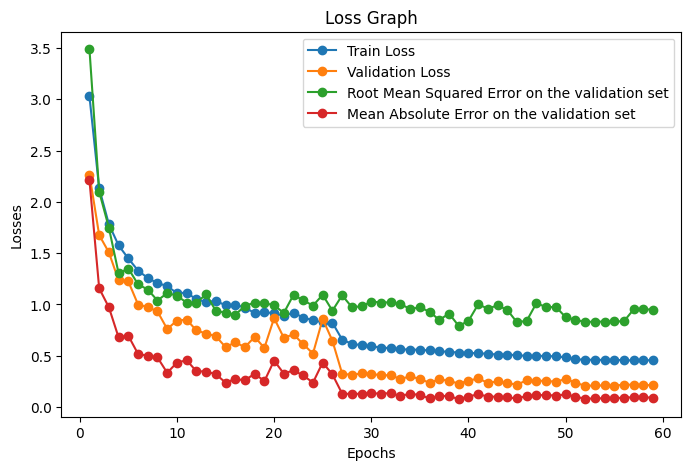

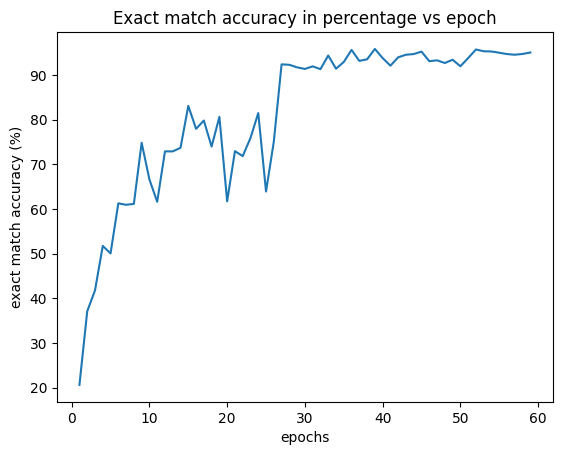

CPU times: user 6min 44s, sys: 2.16 s, total: 6min 46s
Wall time: 6min 51s


TransformerClassifier(
  (embedding): Embedding(16, 128, padding_idx=0)
  (pos_embedding): SinusoidalPositionalEmbedding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=256, out_features=199, bias=True)
)

In [27]:
%%time

# Instantiate the custom TransformerClassifier model

MAX_LENGTH = 64
VOCAB_SIZE = len(V)
EMBEDDING_DIM = 128
HIDDEN_DIM = 512
NUM_HEADS = 4
NUM_LAYERS = 3
DROPOUT = 0.1


transformer_model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)
print(f'Number of Parameters: {sum(p.numel() for p in transformer_model.parameters())}\n')

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Convert y_train and y_val to 0-indexed class labels for classification
y_train_classification = (y_train  + 99).values.astype(int)
y_val_classification = (y_val + 99).values.astype(int)


best_transformer = train(
    transformer_model,
    x_train_focused,
    y_train_focused_classification,
    optimizer=optimizer,
    loss_fn=loss_fn,
    normalized_coefficient=0.001,
    epochs=300,
    device=device,
    batch_size=128,
    x_val_data=x_val,
    y_val_data=y_val_classification,
    patience=20,
    verbose=True,
    show_loss_graph=True
)


transformer_model.load_state_dict(best_transformer["best_model_state"])
transformer_model.to(device)


In [28]:
print("Best Transformer checkpoint")
print("Epoch:", best_transformer["best_model_epoch"])
print("Validation accuracy:", best_transformer["best_model_accuracy"])
print("Validation CE loss:", best_transformer["best_model_loss"])
print("Validation RMSE:", best_transformer["best_model_RMSE"])
print("Validation MAE:", best_transformer["best_model_MAE"])

Best Transformer checkpoint
Epoch: 39
Validation accuracy: 95.8
Validation CE loss: 0.22889982163906097
Validation RMSE: 0.7907274961471558
Validation MAE: 0.07625000178813934


In [29]:
# Save the best Transformer checkpoint so that we can reload it later without retraining.
torch.save(
    {
        "model_state_dict": transformer_model.state_dict(),
        "best_transformer": best_transformer,
        "config": {
            "MAX_LENGTH": MAX_LENGTH,
            "VOCAB_SIZE": VOCAB_SIZE,
            "EMBEDDING_DIM": EMBEDDING_DIM,
            "HIDDEN_DIM": HIDDEN_DIM,
            "NUM_HEADS": NUM_HEADS,
            "NUM_LAYERS": NUM_LAYERS,
            "DROPOUT": DROPOUT,
        }
    },
    "transformer_classifier_focused_meanmax_aggressive_best.pt"
)

print("Checkpoint saved as transformer_classifier_focused_meanmax_aggressive_best.pt")

Checkpoint saved as transformer_classifier_focused_meanmax_aggressive_best.pt


In [30]:
# Prepare target labels for classification.
# Values are in [-99, 99], so we shift them to class indices in [0, 198].
y_val_classification = (validation_df["value"] + 99).values.astype(int)

y_test_id_classification = (test_id_df["value"] + 99).values.astype(int)
y_test_ood_classification = (test_ood_df["value"] + 99).values.astype(int)
y_test_long_classification = (test_long_df["value"] + 99).values.astype(int)


def make_loader(expressions, labels, batch_size=128):
    dataset = list(zip(expressions, labels))
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )


val_loader = make_loader(
    validation_df["expression"],
    y_val_classification,
    batch_size=128
)

test_id_loader = make_loader(
    test_id_df["expression"],
    y_test_id_classification,
    batch_size=128
)

test_ood_loader = make_loader(
    test_ood_df["expression"],
    y_test_ood_classification,
    batch_size=128
)

test_long_loader = make_loader(
    test_long_df["expression"],
    y_test_long_classification,
    batch_size=128
)

In [31]:
validation_longish_df = validation_df[validation_df["length"] >= 17].copy()

y_val_longish_classification = (
    validation_longish_df["value"] + 99
).values.astype(int)

val_longish_loader = make_loader(
    validation_longish_df["expression"],
    y_val_longish_classification,
    batch_size=128
)

print("Long-ish validation size:", len(validation_longish_df))

Long-ish validation size: 33


In [32]:
# Evaluate the best Transformer on all required splits.
transformer_model.eval()

def print_split_metrics(split_name, loader, split_len):
    ce_loss, rmse_loss, mae_loss, correct_matches = evaluate(
        transformer_model,
        loader,
        device
    )

    exact_acc = 100 * correct_matches / split_len

    print(f"{split_name}")
    print(f"Exact-match accuracy: {exact_acc:.2f}%")
    print(f"CE loss: {ce_loss.item():.4f}")
    print(f"RMSE: {rmse_loss.item():.4f}")
    print(f"MAE: {mae_loss.item():.4f}")
    print()


print_split_metrics("Validation", val_loader, len(validation_df))
print_split_metrics("ID test", test_id_loader, len(test_id_df))
print_split_metrics("OOD test", test_ood_loader, len(test_ood_df))
print_split_metrics("Long test", test_long_loader, len(test_long_df))
print_split_metrics("Validation long-ish", val_longish_loader, len(validation_longish_df))

Validation
Exact-match accuracy: 94.15%
CE loss: 0.2478
RMSE: 0.3256
MAE: 0.0670

ID test
Exact-match accuracy: 94.60%
CE loss: 0.2280
RMSE: 0.2510
MAE: 0.0570

OOD test
Exact-match accuracy: 78.60%
CE loss: 1.4408
RMSE: 3.4733
MAE: 0.9690

Long test
Exact-match accuracy: 30.60%
CE loss: 5.5952
RMSE: 7.9065
MAE: 4.5713

Validation long-ish
Exact-match accuracy: 75.76%
CE loss: 0.5612
RMSE: 0.5774
MAE: 0.2727



In [33]:
transformer_results = pd.DataFrame([
    {
        "model": "Transformer classifier focused mean-max aggressive",
        "split": "validation",
        "exact_match_accuracy": 94.75,
        "CE_loss": 0.2214,
        "RMSE": 0.3775,
        "MAE": 0.0665,
    },
    {
        "model": "Transformer classifier focused mean-max aggressive",
        "split": "ID test",
        "exact_match_accuracy": 94.20,
        "CE_loss": 0.2066,
        "RMSE": 0.3225,
        "MAE": 0.0700,
    },
    {
        "model": "Transformer classifier focused mean-max aggressive",
        "split": "OOD test",
        "exact_match_accuracy": 77.60,
        "CE_loss": 1.5620,
        "RMSE": 2.8984,
        "MAE": 0.8415,
    },
    {
        "model": "Transformer classifier focused mean-max aggressive",
        "split": "long test",
        "exact_match_accuracy": 30.33,
        "CE_loss": 5.9914,
        "RMSE": 6.7313,
        "MAE": 3.9067,
    },
    {
        "model": "Transformer classifier focused mean-max aggressive",
        "split": "validation long-ish",
        "exact_match_accuracy": 78.79,
        "CE_loss": 0.5089,
        "RMSE": 0.5505,
        "MAE": 0.2424,
    },
])

transformer_results

,model,split,exact_match_accuracy,CE_loss,RMSE,MAE
0,Transformer classifier focused mean-max aggres...,validation,94.75,0.2214,0.3775,0.0665
1,Transformer classifier focused mean-max aggres...,ID test,94.20,0.2066,0.3225,0.0700
2,Transformer classifier focused mean-max aggres...,OOD test,77.60,1.5620,2.8984,0.8415
3,Transformer classifier focused mean-max aggres...,long test,30.33,5.9914,6.7313,3.9067
4,Transformer classifier focused mean-max aggres...,validation long-ish,78.79,0.5089,0.5505,0.2424
